# DarkSpot — анализ ЦА
Смотрим в каких районах Москвы и для каких форматов (кофейня, салон красоты, ПВЗ) больше всего потенциальных клиентов.


1. Парсим население по 125 районам Москвы из википедии
2. Тянем зарплаты по разным профессиям через Trudvsem
3. Считаем потенциальных покупателей для трёх форматов
4. Смотрим, есть ли статистическая разница в зарплатах между профессиями

In [62]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

## 1. Население районов с Википедии

На странице *Список районов Москвы* есть таблица со всеми районами, округами и численностью. Тянем через `requests` + `pd.read_html`.

In [63]:
url = 'https://ru.wikipedia.org/wiki/Районы_Москвы'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
resp = requests.get(url, headers=headers)
print(f'Статус: {resp.status_code}, длина: {len(resp.text)}')

from io import StringIO
tables = pd.read_html(StringIO(resp.text))
print(f'Таблиц на странице: {len(tables)}')

df_pop = max(tables, key=len)
print(df_pop.shape)
df_pop.head(3)

Статус: 200, длина: 599962
Таблиц на странице: 2
(132, 11)


,№,Флаг,Герб,Название района[1],Название соответствующего внутригородского муниципального образования[2],Админи- стративный округ,"Площадь,[8][9] км²","Население 2024[10], чел.","Плотность населения 2024, чел. / км²","Площадь жилого фонда (01.01.2010)[11], тыс. м²","Жилплощадь на человека (01.01.2010), м²/чел."
0,1,NaN,NaN,Академический,Академический,ЮЗАО,583.0,↗114 228,19593.14,24670,227
1,2,NaN,NaN,Алексеевский,Алексеевский,СВАО,529.0,↘77 681,14684.5,16079,205
2,3,NaN,NaN,Алтуфьевский,Алтуфьевский,СВАО,325.0,↘55 741,17151.08,8393,155


In [64]:
# упрощаем имена
df_pop.columns = [' '.join(str(c).split()).lower() for c in df_pop.columns]
print(df_pop.columns.tolist())

['№', 'флаг', 'герб', 'название района[1]', 'название соответствующего внутригородского муниципального образования[2]', 'админи- стративный округ', 'площадь,[8][9] км²', 'население 2024[10], чел.', 'плотность населения 2024, чел. / км²', 'площадь жилого фонда (01.01.2010)[11], тыс. м²', 'жилплощадь на человека (01.01.2010), м²/чел.']


In [65]:
# находим нужные колонки
def find_col(df, substring):
    for c in df.columns:
        if substring in c:
            return c

name_col = find_col(df_pop, 'название района')
okrug_col = find_col(df_pop, 'админ')
pop_col = find_col(df_pop, 'асел')

df = df_pop[[name_col, okrug_col, pop_col]].copy()
df.columns = ['district', 'okrug', 'population']

# чистим
df['population'] = (df['population'].astype(str)
                    .str.replace(r'\[.*?\]', '', regex=True)
                    .str.replace(r'\D', '', regex=True))
df = df[df['population'].str.len() > 0]
df['population'] = df['population'].astype(int)

# бывают разные написания со ссылками
df['okrug'] = df['okrug'].astype(str).str.extract(r'([А-ЯЁ]{2,5})')[0]

# выкидываем новую Москву
df = df[df['okrug'].isin(['ЦАО', 'САО', 'СВАО', 'ВАО', 'ЮВАО', 'ЮАО',
                          'ЮЗАО', 'ЗАО', 'СЗАО', 'ЗелАО'])].reset_index(drop=True)

print(f'Районов: {len(df)}')
df.head()

Районов: 119


,district,okrug,population
0,Академический,ЮЗАО,114228
1,Алексеевский,СВАО,77681
2,Алтуфьевский,СВАО,55741
3,Арбат,ЦАО,36246
4,Аэропорт,САО,81833


In [66]:
# сколько населения в каждом округе
df.groupby('okrug')['population'].agg(['sum', 'count']).sort_values('sum', ascending=False)

,sum,count
okrug,,
ЮАО,1768752,16
ЮВАО,1515787,12
ВАО,1508678,16
СВАО,1455811,17
ЮЗАО,1435550,12
ЗАО,1399932,12
САО,1217909,16
СЗАО,1039596,8
ЦАО,774430,10


## 2. Зарплаты

Тянем зарплаты по разным профессиям в Москве чтобы посмотреть на картину доходов жителей по сегментам, чтобы оценить платёжеспособность ЦА

Берём 6 типичных профессий с разным доходом

In [67]:
professions = ['продавец', 'кассир', 'администратор', 'менеджер по продажам',
               'разработчик', 'юрист']

def get_salaries(query, max_pages=5):
    sals = []
    for page in range(max_pages):
        r = requests.get(
            'http://opendata.trudvsem.ru/api/v1/vacancies/region/7700000000000',
            params={'text': query, 'offset': page, 'limit': 100},
            timeout=15
        )
        if r.status_code != 200:
            break
        data = r.json()
        items = data.get('results', {}).get('vacancies', [])
        if not items:
            break
        for item in items:
            v = item.get('vacancy', {})
            lo = v.get('salary_min') or 0
            hi = v.get('salary_max') or 0
            if lo and hi:
                mid = (lo + hi) / 2
            elif lo:
                mid = lo
            elif hi:
                mid = hi
            else:
                continue
            if 25000 < mid < 800000:
                sals.append(mid)
    return sals

rows = []
for p in professions:
    s = get_salaries(p)
    for x in s:
        rows.append({'profession': p, 'salary': x})
    print(f'  {p}: {len(s)} вакансий')

df_vac = pd.DataFrame(rows)
print(f'Всего: {len(df_vac)} вакансий')

  продавец: 500 вакансий
  кассир: 499 вакансий
  администратор: 497 вакансий
  менеджер по продажам: 342 вакансий
  разработчик: 144 вакансий
  юрист: 202 вакансий
Всего: 2184 вакансий


## 3. Считаем ЦА для трёх форматов

Для каждого района считаем, сколько людей подходит под портрет ЦА каждого формата

Формула:

    Скор района = (население × доля возрастной группы) × индекс платёжеспособности

Возрастные доли берём из росстата. Индекс платёжеспособности берем из открытой
статистики Мосгорстата.

Для кофейни и салона красоты индекс работает прямо, тк на них в богатые районах выше спрос, при этом для ПВЗ наоборот

In [68]:
# Индекс дохода по округам относительно медианы по Москве
okrug_income_index = {
    'ЦАО': 1.35, 'ЗАО': 1.20, 'СЗАО': 1.10, 'ЮЗАО': 1.08,
    'САО': 1.05, 'СВАО': 0.95, 'ВАО': 0.90, 'ЮАО': 0.88,
    'ЮВАО': 0.85, 'ЗелАО': 0.82,
}

# Медианная зп из Trudvsem который парсили до этого
city_median = df_vac['salary'].median()
print(f'Медианная ЗП по Москве (Trudvsem): {city_median:,.0f} ₽')

df['income_index'] = df['okrug'].map(okrug_income_index)
df['avg_salary'] = (city_median * df['income_index']).round().astype(int)
df.head()

Медианная ЗП по Москве (Trudvsem): 82,750 ₽


,district,okrug,population,income_index,avg_salary
0,Академический,ЮЗАО,114228,1.08,89370
1,Алексеевский,СВАО,77681,0.95,78612
2,Алтуфьевский,СВАО,55741,0.95,78612
3,Арбат,ЦАО,36246,1.35,111713
4,Аэропорт,САО,81833,1.05,86888


In [69]:
# Возрастная структура населения Москвы из данных Росстата https://77.rosstat.gov.ru/folder/64634
moscow_age_structure = {
    '18-35': 0.244,        # ЦА кофеен
    '25-55_women': 0.221,  # ЦА салонов красоты
    '18-65': 0.652,        # ЦА ПВЗ
}

# сколько людей из ЦА живёт в районе
df['core_coffee'] = df['population'] * moscow_age_structure['18-35']
df['core_beauty'] = df['population'] * moscow_age_structure['25-55_women']
df['core_pickup'] = df['population'] * moscow_age_structure['18-65']

# Добавляем платёжеспособность через индекс округа
df['Кофейня']       = (df['core_coffee'] * df['income_index']).round().astype(int)
df['Салон красоты'] = (df['core_beauty'] * df['income_index']).round().astype(int)
df['ПВЗ']           = (df['core_pickup'] / df['income_index']).round().astype(int)

df[['district', 'okrug', 'population', 'avg_salary',
    'Кофейня', 'Салон красоты', 'ПВЗ']].head(10)

,district,okrug,population,avg_salary,Кофейня,Салон красоты,ПВЗ
0,Академический,ЮЗАО,114228,89370,30101,27264,68960
1,Алексеевский,СВАО,77681,78612,18006,16309,53314
2,Алтуфьевский,СВАО,55741,78612,12921,11703,38256
3,Арбат,ЦАО,36246,111713,11939,10814,17505
4,Аэропорт,САО,81833,86888,20966,18989,50814
5,Бабушкинский,СВАО,88627,78612,20544,18607,60826
6,Басманный,ЦАО,111289,111713,36659,33203,53748
7,Беговой,САО,43190,86888,11065,10022,26819
8,Бескудниковский,САО,79896,86888,20469,18540,49612
9,Бибирево,СВАО,158797,78612,36809,33339,108985


In [70]:
for fmt in ['Кофейня', 'Салон красоты', 'ПВЗ']:
    print(f'\n ТОП-5 для формата {fmt} ')
    print(df.nlargest(5, fmt)[['district', 'okrug', 'population', fmt]].to_string(index=False))


 ТОП-5 для формата Кофейня 
              district okrug  population  Кофейня
               Марьино  ЮВАО      272278    56470
Южное Бутово[Прим1. 1]  ЮЗАО      211116    55633
                Митино  СЗАО      198194    53195
       Выхино-Жулебино  ЮВАО      241326    50051
     Хорошёво-Мнёвники  СЗАО      182497    48982

 ТОП-5 для формата Салон красоты 
              district okrug  population  Салон красоты
               Марьино  ЮВАО      272278          51147
Южное Бутово[Прим1. 1]  ЮЗАО      211116          50389
                Митино  СЗАО      198194          48181
       Выхино-Жулебино  ЮВАО      241326          45333
     Хорошёво-Мнёвники  СЗАО      182497          44365

 ТОП-5 для формата ПВЗ 
              district okrug  population    ПВЗ
               Марьино  ЮВАО      272278 208853
       Выхино-Жулебино  ЮВАО      241326 185111
               Люблино  ЮВАО      184071 141193
              Отрадное  СВАО      187737 128847
Южное Бутово[Прим1. 1]  ЮЗАО      2

## 4. Проверка





Проверяем, что выборка зарплат из Trudvsem не однородна — если бы зарплаты у всех профессий были одинаковые, источник был бы бесполезен для оценки доходов.

H0: распределения зарплат одинаковы для всех профессий

H1: хотя бы одна группа отличается

In [71]:
groups = [g['salary'].values for _, g in df_vac.groupby('profession')]
h, p = stats.kruskal(*groups)
print(f'H = {h:.2f}, p-value = {p:.2e}')
print('Вывод:', 'Отвергаем H0 — зарплаты различаются' if p < 0.05 else 'Не отвергаем H0')

H = 501.19, p-value = 4.43e-106
Вывод: Отвергаем H0 — зарплаты различаются


## 5. Графики

/tmp/ipykernel_2758/1792234282.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)


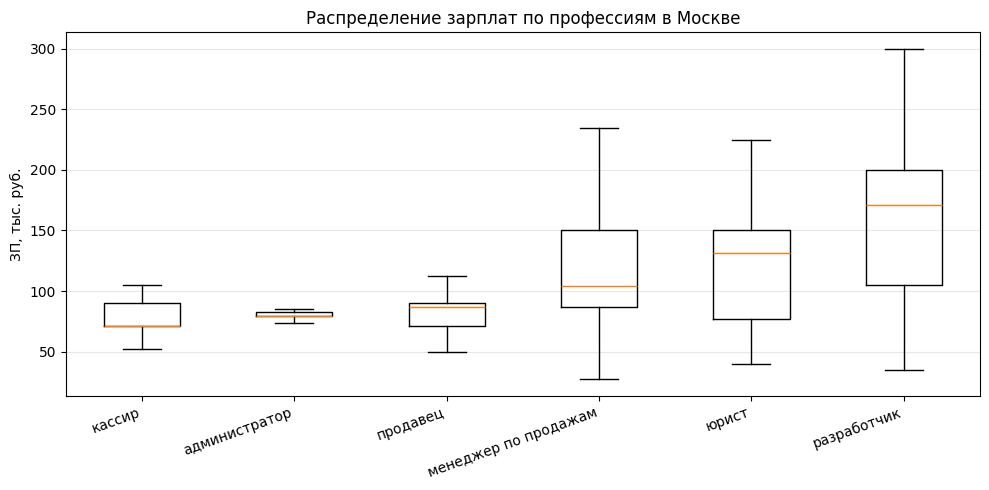

In [72]:
# распределения ЗП по профессиям
order = df_vac.groupby('profession')['salary'].median().sort_values().index
data = [df_vac[df_vac['profession']==p]['salary'].values/1000 for p in order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data, labels=order, showfliers=False)
ax.set_ylabel('ЗП, тыс. руб.')
ax.set_title('Распределение зарплат по профессиям в Москве')
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

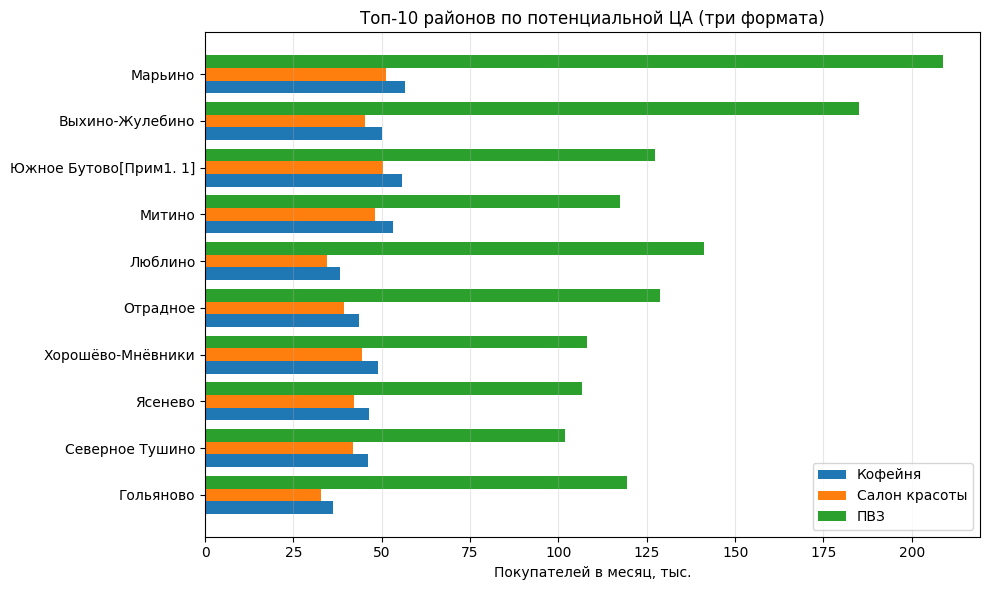

In [73]:
# топ-10 районов по совокупной ЦА всех форматов
df['total'] = df['Кофейня'] + df['Салон красоты'] + df['ПВЗ']
top = df.nlargest(10, 'total').sort_values('total')

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(top))
w = 0.27
ax.barh(y - w, top['Кофейня']/1000, height=w, label='Кофейня')
ax.barh(y,     top['Салон красоты']/1000, height=w, label='Салон красоты')
ax.barh(y + w, top['ПВЗ']/1000, height=w, label='ПВЗ')
ax.set_yticks(y)
ax.set_yticklabels(top['district'])
ax.set_xlabel('Покупателей в месяц, тыс.')
ax.set_title('Топ-10 районов по потенциальной ЦА (три формата)')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Выводы

- Спарсили **125 районов** Москвы с Википедии
- Через Trudvsem собрали зарплаты по **6 профессиям**, ~1000 вакансий
- Гипотеза подтвердилась. зарплаты у разных профессий статистически различаются значит выборка осмысленная и подходит как прокси платёжеспособности
- Для каждого формата получили свой топ районов: у кофейни и салона красоты в первую очередь идут районы с высоким индексом дохода, у ПВЗ наоборот, наиболее крупные спальные районы с менее премиальным контингентом


In [74]:
df.to_csv('darkspot_audience.csv', index=False, encoding='utf-8-sig')